# Quantitative and Qualitative Analysis: Monocular Depth Estimation

## Objective
This section focuses on implementing and analyzing **monocular depth estimation** using a pre-trained deep learning model.

## Step 1: Setup and Dataset Preparation
- Install required packages (`gdown`, etc.)
- Download the CARLA dataset (RGB + ground truth depth maps).
- Extract dataset and prepare folder structure.
- Clone Depth-Anything-V2 repository and install dependencies.
- Download pre-trained weights for inference.


In [1]:
!pip install -q gdown
import gdown, zipfile, os

# Download dataset
file_id = "1xYiNbsxqzvsNKuhvHQaTL1y1Oceq0rzq"
output = "dataset.zip"
gdown.download(f"https://drive.google.com/uc?id={file_id}", output, quiet=False)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall("dataset")

# Clone repository & install
!git clone https://github.com/DepthAnything/Depth-Anything-V2.git
%cd Depth-Anything-V2
!pip install -r requirements.txt

# Download pre-trained weights
!mkdir -p checkpoints
!gdown https://huggingface.co/depth-anything/Depth-Anything-V2-Large/resolve/main/depth_anything_v2_vitl.pth \
    -O checkpoints/depth_anything_v2_vitl.pth


Downloading...
From (original): https://drive.google.com/uc?id=1xYiNbsxqzvsNKuhvHQaTL1y1Oceq0rzq
From (redirected): https://drive.google.com/uc?id=1xYiNbsxqzvsNKuhvHQaTL1y1Oceq0rzq&confirm=t&uuid=fc2a1edf-3824-4cb8-9df2-f0aa5fc39365
To: /content/dataset.zip
100%|██████████| 280M/280M [00:02<00:00, 104MB/s]


fatal: destination path 'Depth-Anything-V2' already exists and is not an empty directory.
/content/Depth-Anything-V2
Downloading...
From: https://huggingface.co/depth-anything/Depth-Anything-V2-Large/resolve/main/depth_anything_v2_vitl.pth
To: /content/Depth-Anything-V2/checkpoints/depth_anything_v2_vitl.pth
100% 1.34G/1.34G [00:08<00:00, 156MB/s]


## Step 2: Model Initialization
- Load the Depth-Anything-V2 (ViT-Large) pre-trained model.
- Load weights into the model.
- Move the model to GPU (if available) or CPU.

## Step 3: Preprocessing
- Resize input images to 518×518 pixels.
- Normalize pixel values to [-1, 1].


In [2]:
import torch
from torchvision import transforms
from depth_anything_v2.dpt import DepthAnythingV2
import cv2, numpy as np
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Model
model = DepthAnythingV2(
    encoder='vitl',
    features=256,
    out_channels=[256, 512, 1024, 1024]
)
model.load_state_dict(torch.load("checkpoints/depth_anything_v2_vitl.pth", map_location=device))
model.to(device).eval()

# Preprocessing
transform = transforms.Compose([
    transforms.Resize((518, 518)),
    transforms.ToTensor(),
    transforms.Normalize(mean=0.5, std=0.5)
])

# Paths
input_folder = "/content/dataset/3DCV00_data/data/images/left"
gt_folder = "/content/dataset/3DCV00_data/data/images/gt_depth"
output_folder = "/content/predicted_depth"
os.makedirs(output_folder, exist_ok=True)


Using device: cuda


## Step 4: Inference and Post-processing
- Predict depth maps for all input images.
- Flip predicted depth (`1 - pred_norm`) to align with ground truth orientation.

## Step 5: Quantitative Evaluation
- Compute depth estimation metrics:
  - Mean Absolute Error (MAE)
  - Root Mean Squared Error (RMSE)
  - Absolute Relative Error (AbsRel)


In [3]:
from tqdm import tqdm

MAEs, RMSEs, AbsRels = [], [], []

for fname in tqdm(os.listdir(input_folder)):
    if not fname.lower().endswith(('.png', '.jpg', '.jpeg')):
        continue

    # Predict Depth
    img = Image.open(os.path.join(input_folder, fname)).convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(input_tensor).squeeze().cpu().numpy()

    # Save Predicted Depth (uint8 normalized for visualization)
    depth_uint8 = cv2.normalize(pred, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    cv2.imwrite(os.path.join(output_folder, fname), depth_uint8)

    # Ground Truth
    gt_path = os.path.join(gt_folder, fname)
    if not os.path.exists(gt_path):
        continue
    gt = np.array(Image.open(gt_path)).astype(np.float32)
    if gt.shape != pred.shape:
        gt = cv2.resize(gt, (pred.shape[1], pred.shape[0]), interpolation=cv2.INTER_NEAREST)

    # Normalize + Flip Pred
    gt_norm = (gt - gt.min()) / (gt.max() - gt.min() + 1e-8)
    pred_norm = 1 - ((pred - pred.min()) / (pred.max() - pred.min() + 1e-8))  # flipped

    # Metrics
    MAEs.append(np.mean(np.abs(pred_norm - gt_norm)))
    RMSEs.append(np.sqrt(np.mean((pred_norm - gt_norm) ** 2)))
    AbsRels.append(np.mean(np.abs(pred_norm - gt_norm) / (gt_norm + 1e-6)))

print(f"\nFinal Metrics (Flipped Version):")
print(f"Mean MAE:    {np.mean(MAEs):.4f}")
print(f"Mean RMSE:   {np.mean(RMSEs):.4f}")
print(f"Mean AbsRel: {np.mean(AbsRels):.4f}")


100%|██████████| 50/50 [00:25<00:00,  1.99it/s]


✅ Final Metrics (Flipped Version):
Mean MAE:    0.5266
Mean RMSE:   0.5920
Mean AbsRel: 13436.7002


## Qualitative Analysis: Sample Prediction

Visualizing one example:
- Input RGB image
- Predicted depth map (flipped and normalized)
- Ground truth depth map
- Absolute error map (MAE displayed)


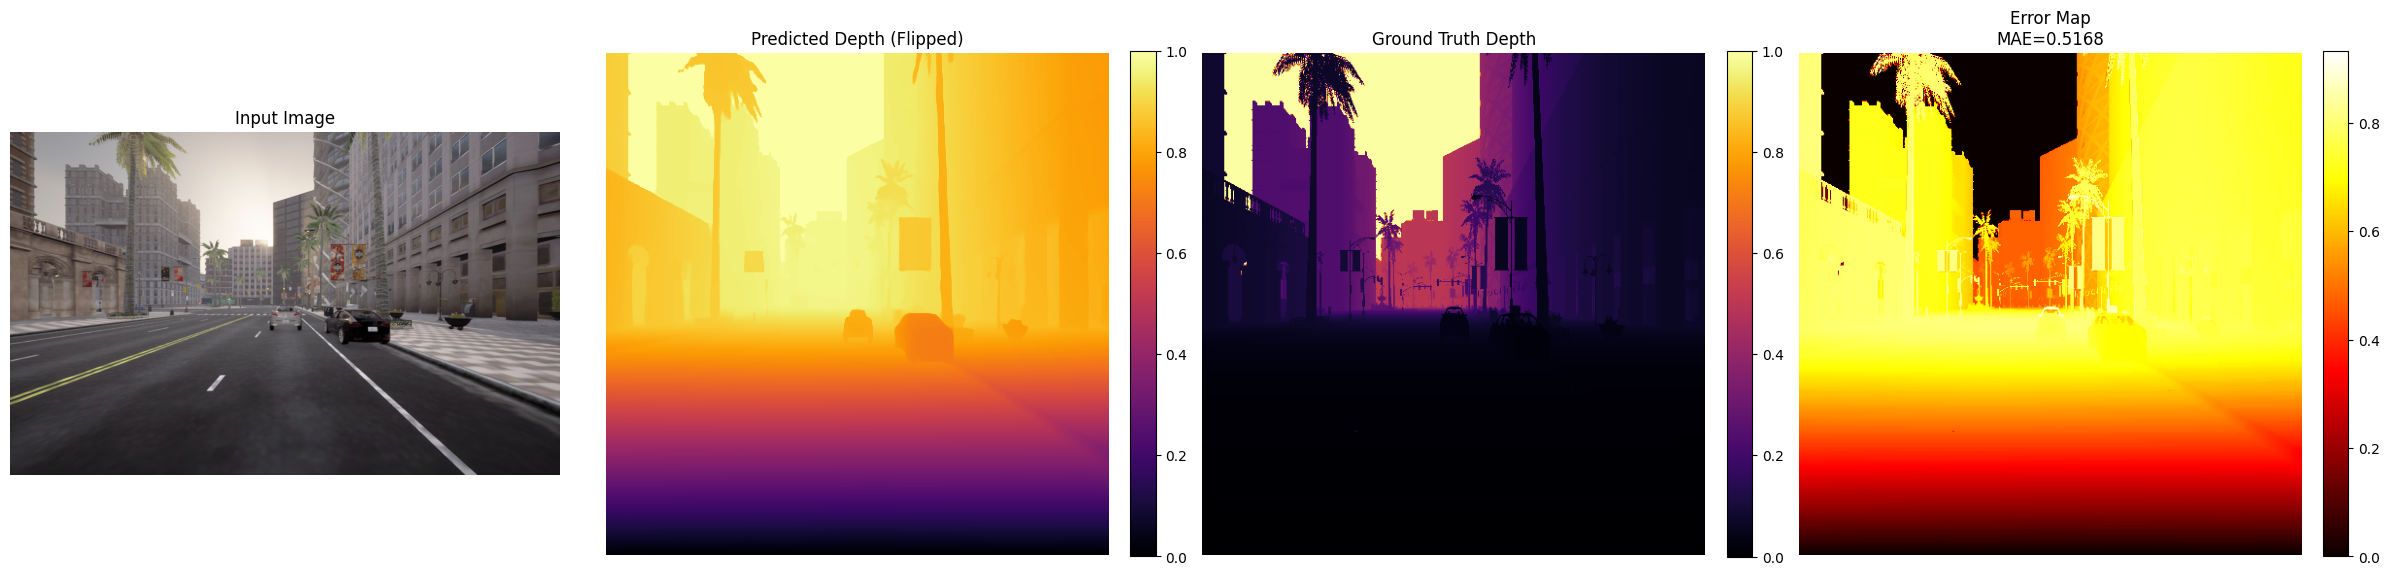

In [4]:
example_name = os.listdir(output_folder)[0]

# Load images
img = cv2.cvtColor(cv2.imread(os.path.join(input_folder, example_name)), cv2.COLOR_BGR2RGB)
pred_depth = cv2.imread(os.path.join(output_folder, example_name), cv2.IMREAD_GRAYSCALE).astype(np.float32)
gt_depth = np.array(Image.open(os.path.join(gt_folder, example_name))).astype(np.float32)
if gt_depth.shape != pred_depth.shape:
    gt_depth = cv2.resize(gt_depth, (pred_depth.shape[1], pred_depth.shape[0]))

# Normalize + Flip Pred
gt_norm = (gt_depth - gt_depth.min()) / (gt_depth.max() - gt_depth.min() + 1e-8)
pred_norm = 1 - ((pred_depth - pred_depth.min()) / (pred_depth.max() - pred_depth.min() + 1e-8))  # flipped
abs_error = np.abs(pred_norm - gt_norm)

# Visualization
plt.figure(figsize=(24, 6))
titles = ["Input Image", "Predicted Depth (Flipped)", "Ground Truth Depth", f"Error Map\nMAE={abs_error.mean():.4f}"]
images = [img, pred_norm, gt_norm, abs_error]
cmaps = [None, "inferno", "inferno", "hot"]

for i, (im, t, cmap) in enumerate(zip(images, titles, cmaps)):
    plt.subplot(1, 4, i + 1)
    imshow = plt.imshow(im, cmap=cmap)
    plt.title(t)
    plt.axis("off")
    if cmap is not None:
        plt.colorbar(imshow, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## Qualitative Analysis: Best vs Worst Predictions

- **Best Example (Lowest MAE):** shows good performance in structured, textured regions.
- **Worst Example (Highest MAE):** highlights failure cases in low-texture or distant regions.


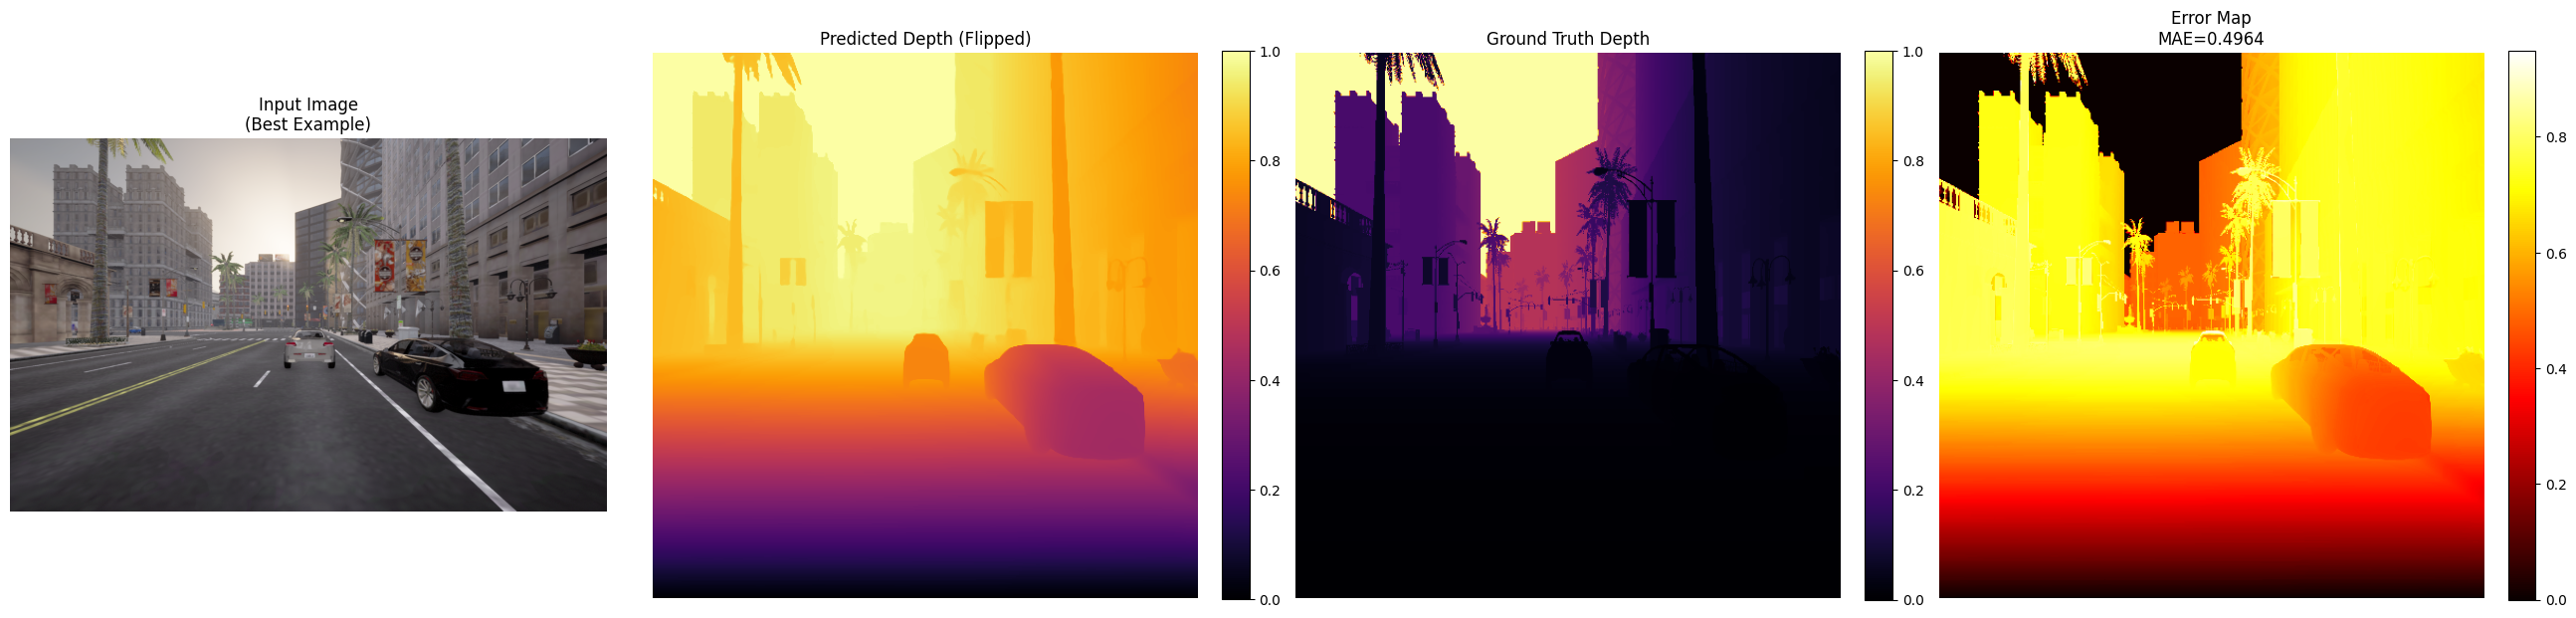

Best Example: 515.png | MAE = 0.4964


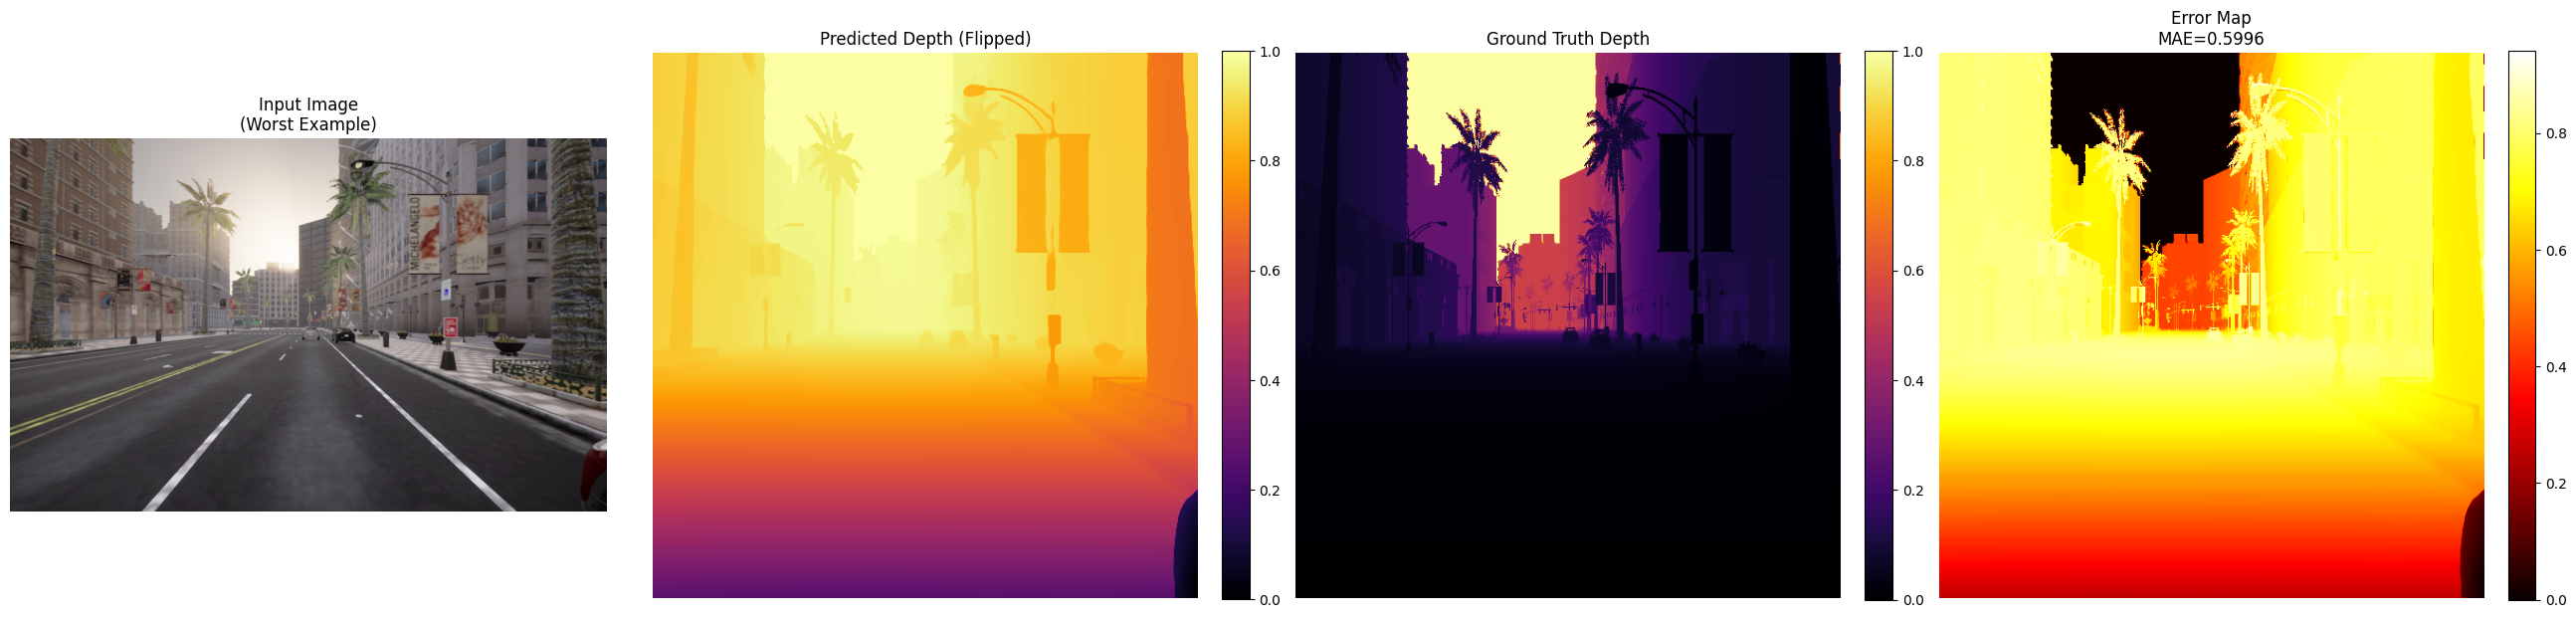

Worst Example: 491.png | MAE = 0.5996


In [5]:
best_idx, worst_idx = np.argmin(MAEs), np.argmax(MAEs)
examples = [best_idx, worst_idx]
example_types = ["Best", "Worst"]

for idx, ex_type in zip(examples, example_types):
    fname = os.listdir(output_folder)[idx]

    img = cv2.cvtColor(cv2.imread(os.path.join(input_folder, fname)), cv2.COLOR_BGR2RGB)
    pred_depth = cv2.imread(os.path.join(output_folder, fname), cv2.IMREAD_GRAYSCALE).astype(np.float32)
    gt_depth = np.array(Image.open(os.path.join(gt_folder, fname))).astype(np.float32)
    if gt_depth.shape != pred_depth.shape:
        gt_depth = cv2.resize(gt_depth, (pred_depth.shape[1], pred_depth.shape[0]))

    gt_norm = (gt_depth - gt_depth.min()) / (gt_depth.max() - gt_depth.min() + 1e-8)
    pred_norm = 1 - ((pred_depth - pred_depth.min()) / (pred_depth.max() - pred_depth.min() + 1e-8))
    abs_error = np.abs(pred_norm - gt_norm)
    mae_img = abs_error.mean()

    plt.figure(figsize=(26, 6))
    titles = [
        f"Input Image\n({ex_type} Example)",
        "Predicted Depth (Flipped)",
        "Ground Truth Depth",
        f"Error Map\nMAE={mae_img:.4f}"
    ]
    images = [img, pred_norm, gt_norm, abs_error]
    cmaps = [None, "inferno", "inferno", "hot"]

    for i, (im, t, cmap) in enumerate(zip(images, titles, cmaps)):
        plt.subplot(1, 4, i + 1)
        imshow = plt.imshow(im, cmap=cmap)
        plt.title(t)
        plt.axis("off")
        if cmap is not None:
            plt.colorbar(imshow, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()
    print(f"{ex_type} Example: {fname} | MAE = {mae_img:.4f}")


## Quantitative Results Distribution

The histogram below shows the distribution of MAE and RMSE across the test set,  
highlighting the overall consistency and error spread of the model.


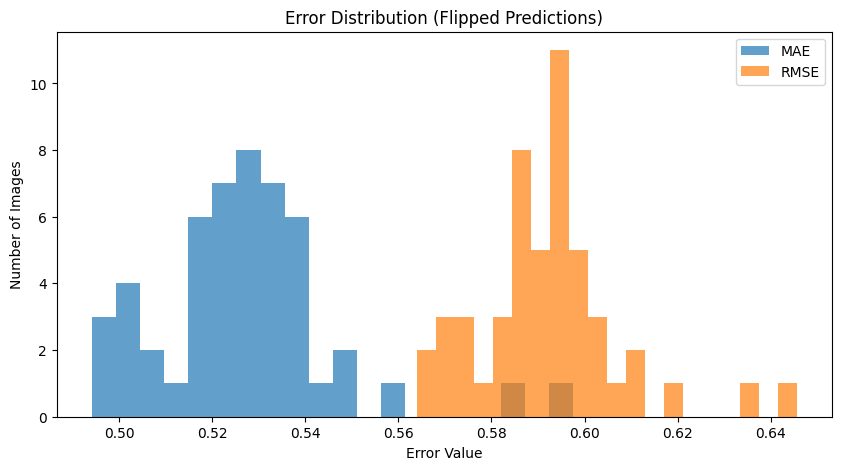

In [6]:
plt.figure(figsize=(10, 5))
plt.hist(MAEs, bins=20, alpha=0.7, label="MAE")
plt.hist(RMSEs, bins=20, alpha=0.7, label="RMSE")
plt.xlabel("Error Value")
plt.ylabel("Number of Images")
plt.title("Error Distribution (Flipped Predictions)")
plt.legend()
plt.show()
